# Sprint 7: ACP y Clustering de IES — versión corregida de perfiles (Issue 7.2)

Este notebook realiza el agrupamiento de las Instituciones de Educacion Superior (IES)
en Colombia segun su desempeno academico en las pruebas Saber Pro y sus metricas SNIES
(matricula, graduacion y acreditacion).

### Pipeline:
1. **Carga memory-safe** de Saber Pro (~2.7M registros, solo columnas necesarias)
2. **Integracion SNIES** respetando la regla MEN de semestres para matricula anual
3. **Feature engineering** por IES (9 variables)
4. **ACP / PCA** para reducir dimensiones (reteniendo >= 70% varianza)
5. **K-Means** sobre las componentes principales reducidas (NO sobre variables originales)
6. **Biplot** de IES en espacio PC1 vs PC2 con vectores de carga
7. **Perfiles de cluster** y auditoria

### Regla MEN para Matricula Anual SNIES:
- **Primer semestre**: se cuenta como matricula anual para TODAS las IES excepto el SENA
- **Segundo semestre**: se cuenta SOLO para el SENA (quienes inician ahi)
- Esto evita duplicaciones y refleja la metodologia oficial del Ministerio de Educacion Nacional


> **Corrección incorporada:** la sección 8 separa desempeño académico, escala institucional y acreditación para evitar interpretaciones engañosas por escalas, imputación y variables binarias.



In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import json
import pickle
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Rutas
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATOS_DIR = PROJECT_ROOT / 'datos' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

# Crear subdirectorios de artifacts si no existen
for subdir in ['modelos', 'metricas', 'visualizaciones']:
    (ARTIFACTS_DIR / subdir).mkdir(parents=True, exist_ok=True)

print("Setup completo!")
print(f"Ruta del proyecto: {PROJECT_ROOT}")

Setup completo!
Ruta del proyecto: c:\Users\German\Pictures\Proyecto-Observatorio-Datos-de-Educacion-en-Colombia


## 1. Carga de Datos (Memory-Safe)
Cargamos unicamente las columnas necesarias del dataset unificado de Saber Pro
(que contiene mas de 2.6M de registros y 150+ columnas originalmente).
Tambien cargamos los datos de SNIES graduados (para el puente de codigos) y el
dataset consolidado que ya aplica la regla MEN de semestres.

### Interpretación — carga de datos

La carga se hace de forma **memory-safe**, seleccionando únicamente las columnas necesarias de Saber Pro para evitar saturar memoria. Esto es importante porque el consolidado contiene millones de registros.

En esta etapa se usan tres fuentes principales:

- **Saber Pro:** aporta desempeño académico por estudiante e IES.
- **SNIES graduados:** sirve como puente para mapear `codigo_snies_programa` hacia `codigo_institucion`.
- **SNIES consolidado:** aporta matrícula y graduados agregados con la regla anual definida previamente.

La lectura correcta de este bloque es metodológica: antes de analizar clusters, se asegura que las variables provengan de fuentes trazables y que el cruce se pueda reproducir.



In [2]:
# Cargar Saber Pro (filtrado por columnas para optimizar la RAM)
print("Cargando Saber Pro...")
df_saberpro = pd.read_parquet(
    DATOS_DIR / 'saber_pro' / 'saber_pro_consolidado.parquet',
    columns=['nombre_ies', 'puntaje_global', 'punt_razona_cuantitativa',
             'punt_lectura_critica', 'punt_ingles', 'estu_consecutivo', 'codigo_snies_programa']
)
print(f"Saber Pro cargado: {len(df_saberpro):,} registros, {df_saberpro.memory_usage(deep=True).sum()/1e6:.1f} MB")

Cargando Saber Pro...


Saber Pro cargado: 2,683,632 registros, 312.7 MB


## 2. Integracion y Creacion de Features Agregadas por IES (Saber Pro + SNIES)

Calculamos 9 features por cada IES cruzando Saber Pro con SNIES:

| # | Feature | Fuente |
|---|---------|--------|
| 1 | `puntaje_global` (mediana) | Saber Pro |
| 2 | `punt_razona_cuantitativa` (promedio) | Saber Pro |
| 3 | `punt_lectura_critica` (promedio) | Saber Pro |
| 4 | `punt_ingles` (promedio) | Saber Pro |
| 5 | `n_presentaciones` (conteo) | Saber Pro |
| 6 | `prop_p75_plus` (proporcion en percentil 75+) | Saber Pro |
| 7 | `total_matriculados` (promedio anual, regla MEN) | SNIES |
| 8 | `total_graduados` (promedio anual) | SNIES |
| 9 | `es_acreditada` (binario) | SNIES |

**Puente Saber Pro <-> SNIES:** usamos `codigo_snies_programa` como llave comun.

**Regla MEN:** `dataset_snies_consolidado.parquet` ya aplica Sem1 todas IES + Sem2 solo SENA.

### Interpretación — integración Saber Pro + SNIES

El dataframe final por IES combina dos dimensiones distintas:

1. **Resultados académicos:** puntajes promedio de Saber Pro y proporción de estudiantes en percentil 75 o superior.
2. **Escala institucional:** número de presentaciones, matrícula, graduados y acreditación.

Hay que tener cuidado con la interpretación de `total_matriculados` y `total_graduados`: estas variables vienen del cruce con SNIES y pueden tener valores faltantes. En el notebook se imputan con la mediana global, lo cual permite ejecutar PCA/K-Means sin perder IES, pero puede hacer que la **mediana por cluster** quede artificialmente similar. Por eso en la sección 8 corregida se usa la **media** y además un boxplot en escala `log1p`.



In [3]:
print("Creando features de Saber Pro por IES...")

# Puntajes promedio por IES
features_ies = df_saberpro.groupby('nombre_ies').agg({
    'puntaje_global': 'mean',
    'punt_razona_cuantitativa': 'mean',
    'punt_lectura_critica': 'mean',
    'punt_ingles': 'mean',
    'estu_consecutivo': 'count'
}).rename(columns={'estu_consecutivo': 'n_presentaciones'})

# Calcular proporcion en P75+ (optimizado para memoria)
print("Calculando proporcion P75+...")
p75_global = df_saberpro['puntaje_global'].quantile(0.75)

df_temp = df_saberpro[['nombre_ies', 'puntaje_global']].copy()
df_temp['es_p75_plus'] = (df_temp['puntaje_global'] >= p75_global).astype(int)
prop_p75 = df_temp.groupby('nombre_ies')['es_p75_plus'].mean().rename('prop_p75_plus')
del df_temp  # Liberar memoria

features_ies = features_ies.join(prop_p75)

print("Cruzando con datos del SNIES usando codigo SNIES de programa...")

# 1. Cargar SNIES Graduados crudo para mapear codigo de programa a codigo de IES
df_grad_raw = pd.read_parquet(
    DATOS_DIR / 'snies' / 'snies_graduados_limpio_consolidado.parquet',
    columns=['codigo_snies_programa', 'codigo_institucion', 'ies_acreditada']
)
df_grad_raw['codigo_snies_programa'] = pd.to_numeric(df_grad_raw['codigo_snies_programa'], errors='coerce')
df_grad_raw = df_grad_raw.dropna(subset=['codigo_snies_programa'])

# Relacion unica programa-IES
prog_to_ies = df_grad_raw[['codigo_snies_programa', 'codigo_institucion']].drop_duplicates().dropna()

# 2. Relacion programa-IES en Saber Pro
sp_prog = df_saberpro[['nombre_ies', 'codigo_snies_programa']].drop_duplicates().dropna()
sp_prog['codigo_snies_programa'] = pd.to_numeric(sp_prog['codigo_snies_programa'], errors='coerce')
sp_prog = sp_prog.dropna()

# 3. Cruzar para obtener el mapeo nombre_ies -> codigo_institucion (SNIES)
merged_bridge = pd.merge(sp_prog, prog_to_ies, on='codigo_snies_programa', how='inner')
ies_mapping = merged_bridge.groupby('nombre_ies')['codigo_institucion'].agg(lambda x: x.value_counts().index[0]).reset_index()

# 4. Cargar dataset consolidado de SNIES (YA implementa regla MEN: Sem1 todas + Sem2 solo SENA)
df_snies = pd.read_parquet(DATOS_DIR / 'snies' / 'dataset_snies_consolidado.parquet')

# Promedio anual de graduados y matriculados de SNIES
snies_agg = df_snies.groupby('codigo_institucion').agg({
    'total_matriculados': 'mean',
    'total_graduados': 'mean'
}).reset_index()

# 5. Obtener acreditacion (SI / NO) por IES
df_grad_raw['es_acreditada'] = df_grad_raw['ies_acreditada'].apply(lambda x: 1 if str(x).strip().upper() in ['SI', 'S', '1'] else 0)
ies_acred = df_grad_raw.groupby('codigo_institucion')['es_acreditada'].max().reset_index()

# Unificar agregaciones de SNIES
snies_agg = pd.merge(snies_agg, ies_acred, on='codigo_institucion', how='left')

# Cruzar SNIES con el mapping de nombres
snies_mapped = pd.merge(ies_mapping, snies_agg, on='codigo_institucion', how='inner')

# 6. Unificar features en features_ies
features_ies = pd.merge(features_ies, snies_mapped[['nombre_ies', 'total_matriculados', 'total_graduados', 'es_acreditada']],
                        on='nombre_ies', how='left')

# Filtrar IES con al menos 100 presentaciones para evitar ruido
features_ies = features_ies[features_ies['n_presentaciones'] >= 100].copy()

# Imputar valores nulos de SNIES con la mediana
features_ies['total_matriculados'] = features_ies['total_matriculados'].fillna(features_ies['total_matriculados'].median())
features_ies['total_graduados'] = features_ies['total_graduados'].fillna(features_ies['total_graduados'].median())
features_ies['es_acreditada'] = features_ies['es_acreditada'].fillna(0).astype(int)

# Establecer nombre_ies como indice
features_ies = features_ies.set_index('nombre_ies')

print(f"\nFeatures integradas creadas para {len(features_ies)} IES con >= 100 presentaciones.")
print(f"Variables: {features_ies.columns.tolist()}")
display(features_ies.head(10))

Creando features de Saber Pro por IES...


Calculando proporcion P75+...


Cruzando con datos del SNIES usando codigo SNIES de programa...



Features integradas creadas para 336 IES con >= 100 presentaciones.
Variables: ['puntaje_global', 'punt_razona_cuantitativa', 'punt_lectura_critica', 'punt_ingles', 'n_presentaciones', 'prop_p75_plus', 'total_matriculados', 'total_graduados', 'es_acreditada']


,puntaje_global,punt_razona_cuantitativa,punt_lectura_critica,punt_ingles,n_presentaciones,prop_p75_plus,total_matriculados,total_graduados,es_acreditada
nombre_ies,,,,,,,,,
CENTRO DE EDUCACION MILITAR-BOGOTÃ D.C.,125.365697,135.023394,125.753211,137.469037,218,0.366972,639.800000,747.700000,0
COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACION-CESA-BOGOTÃ D.C.,167.599080,165.724499,161.830191,194.125583,2196,0.838798,1752.000000,507.500000,1
COLEGIO MAYOR DE ANTIOQUIA-MEDELLIN,134.239433,136.093550,138.840590,136.617670,4713,0.254615,4702.900000,746.700000,1
COLEGIO MAYOR DE BOLIVAR-CARTAGENA,68.701544,64.827121,68.618915,75.748192,719,0.034771,2287.800000,641.800000,0
COLEGIO MAYOR DE NUESTRA SEÃORA DEL ROSARIO-BOGOTÃ D.C.,163.442073,154.166587,164.401029,183.149454,15943,0.747538,11760.818182,3426.454545,1
COLEGIO MAYOR DEL CAUCA-POPAYAN,120.756553,122.428387,121.660000,123.670676,2945,0.096435,2221.100000,532.200000,0
CONSERVATORIO DEL TOLIMA-IBAGUE,127.802783,124.304717,135.276887,137.891274,424,0.231132,382.200000,52.100000,1
CORPORACION ACADEMIA SUPERIOR DE ARTES-MEDELLIN,10.165111,9.863889,10.314815,10.463426,108,0.000000,256.500000,49.400000,0
CORPORACION COLEGIATURA COLOMBIANA-MEDELLIN,136.990625,128.300799,137.410392,168.258833,1251,0.354916,776.100000,162.100000,0


## 3. Analisis de Correlacion de Variables
Analizamos como se correlacionan las 9 features a nivel de IES.
Esto nos da una primera intuicion de por que el PCA podra reducir dimensiones:
variables altamente correlacionadas seran capturadas por una misma componente principal.

### Interpretación — correlaciones

La matriz de correlación permite ver si hay variables redundantes antes del PCA.

- Los puntajes de Saber Pro tienden a moverse juntos; por eso forman una dimensión académica común.
- `prop_p75_plus` complementa los puntajes porque captura concentración de estudiantes con desempeño alto.
- Las variables de escala (`n_presentaciones`, `total_matriculados`, `total_graduados`) no necesariamente equivalen a mejor desempeño: una IES grande puede tener muchos estudiantes y graduados, pero no necesariamente mejores puntajes.
- `es_acreditada` debe leerse como indicador binario; su correlación ayuda, pero no reemplaza una lectura por proporciones.

Esta sección justifica el uso de PCA: reduce redundancia entre variables correlacionadas y separa dimensiones latentes como desempeño académico y tamaño institucional.



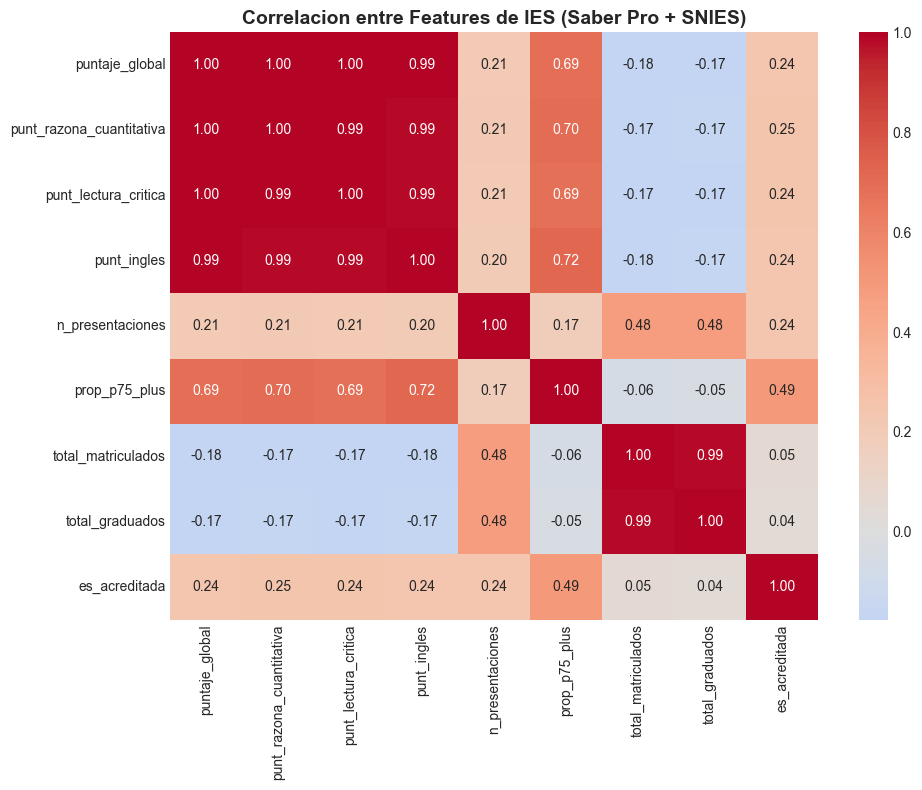

In [4]:
# Correlacion entre features
plt.figure(figsize=(10, 8))
sns.heatmap(features_ies.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlacion entre Features de IES (Saber Pro + SNIES)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Normalizacion y Analisis de Componentes Principales (ACP / PCA)

**Paso critico:** Dado que las variables tienen diferentes escalas (puntajes ~150,
matriculados ~10,000, binario 0/1), las normalizamos a media=0 y desviacion estandar=1.

Luego aplicamos PCA para:
1. **Analizar** cuantas componentes explican >= 70% de la varianza total
2. **REDUCIR** las dimensiones de entrada al clustering a ese numero de componentes

> **IMPORTANTE:** El clustering K-Means se entrena sobre las **componentes principales
> reducidas**, NO sobre las 9 variables originales. Esto elimina multicolinealidad
> y ruido de variables redundantes.

### Interpretación — normalización y PCA

La normalización es obligatoria porque las variables están en escalas muy diferentes: puntajes alrededor de decenas/centenas, matrícula en miles y acreditación en 0/1.

El PCA transforma esas variables en componentes principales:

- **PC1** suele capturar el gradiente de desempeño académico cuando los puntajes y `prop_p75_plus` tienen cargas altas.
- **PC2** suele capturar escala institucional cuando pesan matrícula, graduados o número de presentaciones.

Esto evita que K-Means agrupe solamente por tamaño o por la variable con mayor escala numérica. El clustering se hace sobre componentes reducidas, no sobre variables crudas.



In [5]:
# Normalizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_ies)

# PCA COMPLETO para analizar la varianza de TODAS las componentes
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada Componente Principal:")
for i, var in enumerate(varianza_explicada):
    marker = " <-- " if varianza_acumulada[i] >= 0.70 and (i == 0 or varianza_acumulada[i-1] < 0.70) else ""
    print(f"  PC{i+1}: {var*100:.2f}% (Acumulada: {varianza_acumulada[i]*100:.2f}%){marker}")

# Determinar numero optimo de componentes (>= 70% varianza)
N_COMPONENTS = int(np.argmax(varianza_acumulada >= 0.70) + 1)
print(f"\n>>> Componentes necesarias para >= 70% varianza: {N_COMPONENTS}")
print(f">>> Reduccion de dimensiones: {X_scaled.shape[1]} variables -> {N_COMPONENTS} componentes principales")

Varianza explicada por cada Componente Principal:
  PC1: 52.85% (Acumulada: 52.85%)
  PC2: 26.22% (Acumulada: 79.07%) <-- 
  PC3: 10.94% (Acumulada: 90.01%)
  PC4: 6.36% (Acumulada: 96.38%)
  PC5: 3.29% (Acumulada: 99.67%)
  PC6: 0.14% (Acumulada: 99.81%)
  PC7: 0.11% (Acumulada: 99.93%)
  PC8: 0.07% (Acumulada: 100.00%)
  PC9: 0.00% (Acumulada: 100.00%)

>>> Componentes necesarias para >= 70% varianza: 2
>>> Reduccion de dimensiones: 9 variables -> 2 componentes principales


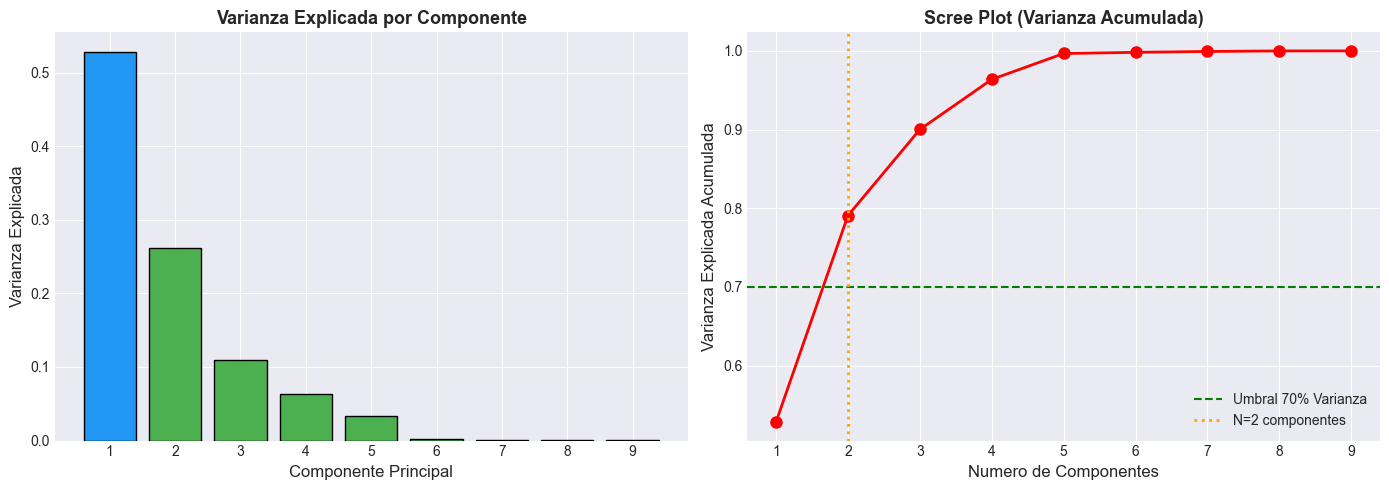

In [6]:
# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de varianza por componente
colors = ['#2196F3' if varianza_acumulada[i] < 0.70 else '#4CAF50' for i in range(len(varianza_explicada))]
axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, color=colors, edgecolor='black')
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada', fontsize=12)
axes[0].set_title('Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, len(varianza_explicada)+1))

# Lineplot de varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Explicada Acumulada', fontsize=12)
axes[1].set_title('Scree Plot (Varianza Acumulada)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, len(varianza_acumulada)+1))
axes[1].axhline(y=0.7, color='g', linestyle='--', label='Umbral 70% Varianza')
axes[1].axvline(x=N_COMPONENTS, color='orange', linestyle=':', lw=2, label=f'N={N_COMPONENTS} componentes')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# =====================================================================
# REDUCCION DE DIMENSIONES: Proyectar datos a N_COMPONENTS principales
# =====================================================================
# Este es el paso critico: K-Means se entrenara sobre X_pca_reduced,
# NO sobre X_scaled (que tiene 9 dimensiones con multicolinealidad)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca_reduced = pca.fit_transform(X_scaled)

print(f"Matriz de entrada al clustering:")
print(f"  Antes (X_scaled):       {X_scaled.shape[0]} IES x {X_scaled.shape[1]} variables")
print(f"  Despues (X_pca_reduced): {X_pca_reduced.shape[0]} IES x {X_pca_reduced.shape[1]} componentes")
print(f"  Varianza retenida: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Mostrar tabla de loadings (contribucion de cada variable a cada PC)
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=features_ies.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)
print(f"\nLoadings (contribucion de cada variable a cada componente):")
display(loadings_df.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.3f}'))

Matriz de entrada al clustering:
  Antes (X_scaled):       336 IES x 9 variables
  Despues (X_pca_reduced): 336 IES x 2 componentes
  Varianza retenida: 79.1%

Loadings (contribucion de cada variable a cada componente):


,PC1,PC2
puntaje_global,0.450,0.006
punt_razona_cuantitativa,0.450,0.009
punt_lectura_critica,0.449,0.007
punt_ingles,0.451,0.006
n_presentaciones,0.101,0.474
prop_p75_plus,0.364,0.088
total_matriculados,-0.099,0.609
total_graduados,-0.097,0.608
es_acreditada,0.168,0.164


## 5. Seleccion del Numero Optimo de Clusters (K)
Probamos K de 2 a 10 usando **las componentes principales reducidas** (no las variables
originales). Evaluamos con Inercia (WCSS), Silhouette Score y Davies-Bouldin Index.

### Interpretación — selección de K

La selección del número de clusters se apoya en métricas complementarias:

- **Inercia:** mide compacidad, pero siempre baja al aumentar K.
- **Silhouette:** evalúa separación entre grupos; valores más altos indican clusters más diferenciados.
- **Davies-Bouldin:** valores más bajos indican mejor separación/compacidad.

La decisión final no debe ser puramente mecánica: también debe ser interpretable para el problema. En este caso, pocos clusters permiten distinguir un grupo de desempeño académico relativamente favorable frente a un grupo crítico.



In [8]:
# Probar diferentes valores de K sobre X_pca_reduced
K_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("Calculando metricas para K = 2 a 10 (sobre componentes PCA reducidas)...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_reduced)  # <-- SOBRE PCA REDUCIDO

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_reduced, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_pca_reduced, labels))

# Tabla resumen
df_metrics = pd.DataFrame({
    'K': list(K_range),
    'Inercia': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores
}).set_index('K')

print("\nResumen de metricas por K:")
display(df_metrics.style.highlight_max(subset=['Silhouette'], color='lightgreen')
                        .highlight_min(subset=['Davies-Bouldin'], color='lightyellow')
                        .format('{:.3f}'))

Calculando metricas para K = 2 a 10 (sobre componentes PCA reducidas)...



Resumen de metricas por K:


,Inercia,Silhouette,Davies-Bouldin
K,,,
2,1139.383,0.675,0.554
3,594.123,0.675,0.367
4,373.046,0.494,0.577
5,295.665,0.497,0.570
6,228.831,0.477,0.612
7,176.191,0.463,0.633
8,146.111,0.433,0.655
9,124.721,0.457,0.637
10,105.457,0.462,0.601


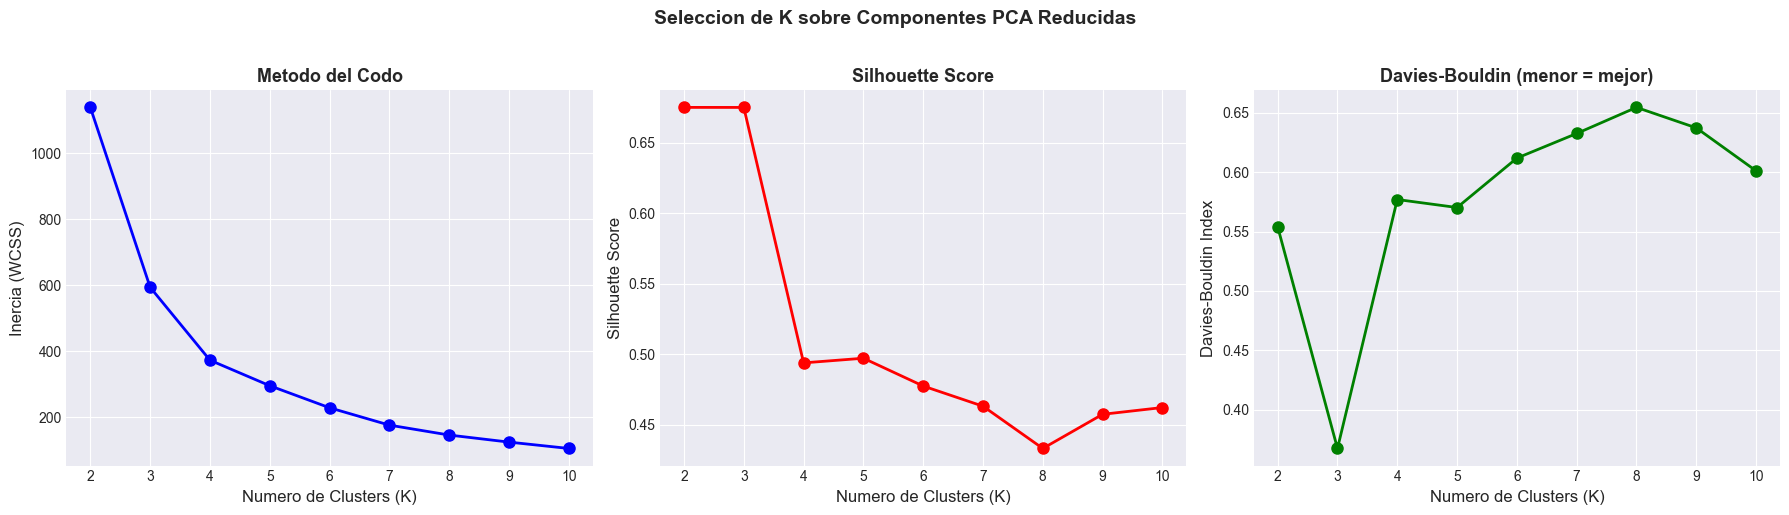

In [9]:
# Visualizar metodo del codo y silhouette
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Metodo del codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Metodo del Codo', fontsize=13, fontweight='bold')
axes[0].set_xticks(K_range)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xticks(K_range)

# Davies-Bouldin Index
axes[2].plot(K_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Numero de Clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin (menor = mejor)', fontsize=13, fontweight='bold')
axes[2].set_xticks(K_range)

plt.suptitle('Seleccion de K sobre Componentes PCA Reducidas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Entrenamiento del Modelo Final (K-Means sobre PCA Reducido)
Entrenamos el modelo con el K optimo (seleccionado por Silhouette Score maximo)
sobre las **componentes principales reducidas**.

### Interpretación — modelo final de clustering

El K-Means final asigna cada IES a un cluster usando las componentes principales retenidas. Esto significa que los grupos resumen patrones multivariados y no solo una variable aislada.

La lectura clave es:

- Un cluster puede tener mejor desempeño académico.
- Otro puede tener mayor escala institucional.
- Esas dos cosas no son equivalentes.

Por eso la sección 8 corregida separa desempeño, escala y acreditación, evitando concluir erróneamente que más matrícula o más graduados implican mejor calidad académica.

- El cluster con mayor tamaño concentra IES con puntajes globales y disciplinares notablemente superiores, mientras que el cluster pequeño agrupa instituciones con puntajes promedio extremadamente bajos, lo que motiva etiquetarlo como grupo de "desempeño crítico".
- Estos resultados sugieren que, en el periodo analizado, existe una segmentación fuerte del sistema de educación superior entre un subconjunto de IES con desempeño muy bajo y el resto con niveles de rendimiento sustancialmente mejores.


In [10]:
# Seleccionar K optimo basado en Silhouette Score maximo
K_OPTIMO = list(K_range)[np.argmax(silhouette_scores)]
print(f"K optimo seleccionado: {K_OPTIMO} (Silhouette: {max(silhouette_scores):.3f})")

# Entrenar K-Means SOBRE PCA REDUCIDO
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20)
labels_final = kmeans_final.fit_predict(X_pca_reduced)  # <-- SOBRE PCA REDUCIDO

# Agregar la etiqueta del cluster al dataframe original
features_ies['cluster'] = labels_final

# Metricas de calidad
silh_final = silhouette_score(X_pca_reduced, labels_final)
db_final = davies_bouldin_score(X_pca_reduced, labels_final)
ch_final = calinski_harabasz_score(X_pca_reduced, labels_final)

print(f"\nMetricas del modelo de K={K_OPTIMO} clusters (sobre {N_COMPONENTS} componentes PCA):")
print(f"  Silhouette Score:        {silh_final:.3f}")
print(f"  Davies-Bouldin Index:    {db_final:.3f}")
print(f"  Calinski-Harabasz Score: {ch_final:.1f}")

print(f"\nDistribucion de IES por cluster:")
print(features_ies['cluster'].value_counts().sort_index())

K optimo seleccionado: 2 (Silhouette: 0.675)

Metricas del modelo de K=2 clusters (sobre 2 componentes PCA):
  Silhouette Score:        0.675
  Davies-Bouldin Index:    0.554
  Calinski-Harabasz Score: 367.0

Distribucion de IES por cluster:
cluster
0    267
1     69
Name: count, dtype: int64


## 7. Visualizacion del Espacio PCA y Biplot
Graficamos la proyeccion de las IES en el plano PC1 vs PC2 y superponemos los
vectores de carga de cada variable original (Biplot) para entender que variables
determinan la formacion de los clusters.

> Las IES estan coloreadas por su cluster asignado (entrenado sobre las dimensiones
> PCA reducidas, no sobre las variables originales).

### Interpretación — biplot PCA

El biplot muestra simultáneamente las IES, los clusters y las direcciones de las variables originales.

- Si las flechas de puntajes apuntan en dirección similar, representan una dimensión común de desempeño académico.
- Si matrícula/graduados/presentaciones apuntan hacia otra dirección, sugieren una dimensión de escala institucional.
- La distancia entre grupos en el plano PCA indica que los clusters tienen perfiles diferenciables.

La interpretación recomendada es mirar la posición de los clusters respecto a las flechas: no solo quién está arriba o abajo, sino qué variables explican esa ubicación.



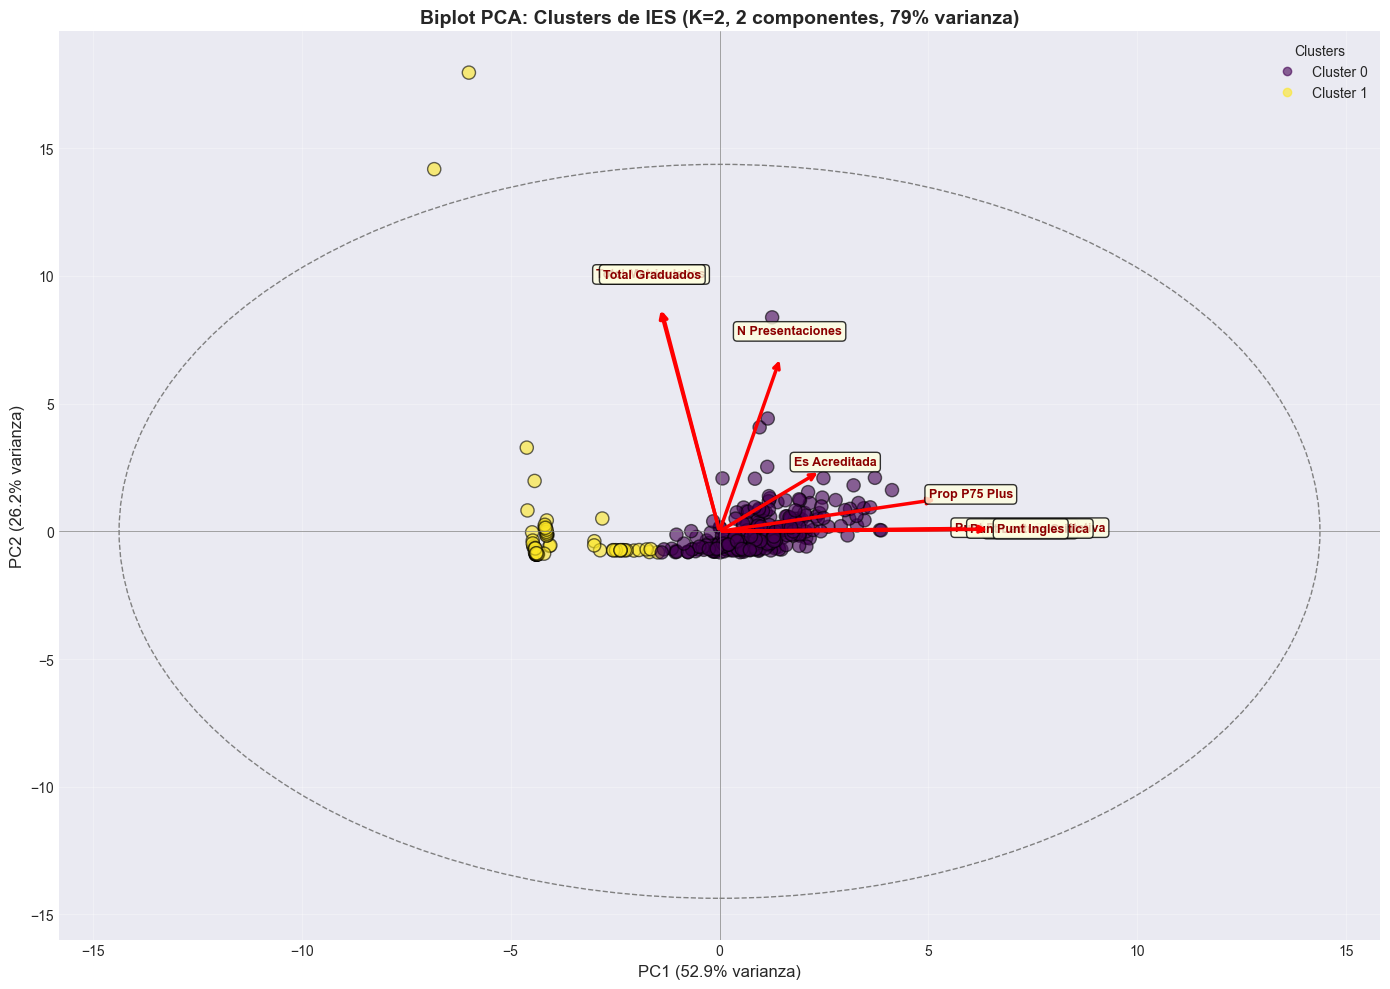

In [11]:
# === BIPLOT PCA y Clusters de IES ===
# Siempre usamos las 2 primeras componentes para la visualizacion
X_pca_2d = X_pca_reduced[:, :2] if X_pca_reduced.shape[1] >= 2 else pca.transform(X_scaled)[:, :2]

fig, ax = plt.subplots(figsize=(14, 10))

# Scatter de IES en espacio PCA coloreado por Cluster
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_final,
                     cmap='viridis', alpha=0.6, s=90, edgecolors='k')

# Obtener loadings (direccion y magnitud de variables originales en PCA)
loadings = pca.components_.T
feature_names_pca = features_ies.drop(columns=['cluster'], errors='ignore').columns.tolist()

# Escalar flechas
scale = np.abs(X_pca_2d).max() * 0.8

for j, fname in enumerate(feature_names_pca):
    ax.annotate('',
        xy=(loadings[j, 0] * scale, loadings[j, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='red', lw=2.5)
    )
    # Etiqueta de la variable
    ax.text(loadings[j, 0] * scale * 1.15,
            loadings[j, 1] * scale * 1.15,
            fname.replace('_', ' ').title(),
            fontsize=9, fontweight='bold', color='darkred',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Circulo unitario de referencia
circle = plt.Circle((0, 0), scale, fill=False, color='gray', linestyle='--', lw=1)
ax.add_patch(circle)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title(f'Biplot PCA: Clusters de IES (K={K_OPTIMO}, {N_COMPONENTS} componentes, {pca.explained_variance_ratio_.sum()*100:.0f}% varianza)',
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='-', lw=0.5)
ax.axvline(x=0, color='gray', linestyle='-', lw=0.5)
ax.grid(True, alpha=0.3)

# Leyenda
handles, _ = scatter.legend_elements()
legend_labels = [f'Cluster {i}' for i in range(len(handles))]
ax.legend(handles, legend_labels, title='Clusters', loc='best')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / f'clusters_ies_pca_biplot_{datetime.now().strftime("%Y%m%d")}.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Interpretación del biplot PCA con clusters de IES

- En el plano PC1–PC2, el eje horizontal (PC1) organiza a las IES desde instituciones con puntajes promedio muy bajos hacia instituciones con puntajes y proporción en P75+ altos, reflejando un gradiente claro de calidad académica.
- El eje vertical (PC2) separa principalmente por escala: IES con muchos matriculados, graduados y presentaciones aparecen en la parte superior, mientras que instituciones más pequeñas se ubican en la parte inferior del plano.
- Los vectores de carga muestran que los cuatro puntajes y la proporción P75+ apuntan en direcciones muy similares, reforzando que son indicadores redundantes de una misma dimensión de desempeño académico.
- Los clusters aparecen bien separados: el grupo de desempeño crítico se concentra en la región de PC1 muy negativa, mientras que el cluster de mejor desempeño se distribuye hacia valores de PC1 positivos, lo que facilita interpretar cada cluster en función de la combinación de calidad y tamaño.

<!-- AUTO_INTERPRETACION_biplot -->

## 8. Análisis de perfiles por cluster

Esta sección corrige la lectura de perfiles separando las variables según su naturaleza. Para las **competencias Saber Pro** se usa **mediana en escala original**, porque es la comparación más intuitiva y evita que valores extremos distorsionen el perfil del cluster.

La lectura queda así:

1. **Competencias y desempeño Saber Pro:** comparación por **mediana cruda** (`puntaje_global`, razonamiento cuantitativo, lectura crítica, inglés y proporción P75+).
2. **Escala institucional:** `n_presentaciones`, `total_matriculados` y `total_graduados` se interpretan por **media** y se acompañan con boxplot `log1p` para revisar asimetrías.
3. **Acreditación:** se interpreta como **porcentaje de IES acreditadas**, no por mediana.



### Interpretación de resultados, sección 8

#### Competencias Saber Pro — comparación por mediana

La comparación principal de competencias se hace con **medianas en escala original**, no con z-score. El resultado separa fuertemente los clusters:

| Variable | Cluster 0 | Cluster 1 | Diferencia C0 - C1 |
|---|---:|---:|---:|
| Puntaje global | 131.11 | 10.03 | +121.08 |
| Razonamiento cuantitativo | 129.81 | 9.93 | +119.88 |
| Lectura crítica | 134.03 | 10.24 | +123.79 |
| Inglés | 136.32 | 10.06 | +126.26 |
| Proporción P75+ | 0.19 | 0.00 | +0.19 |

Esto indica que el **cluster 0** concentra IES con desempeño académico claramente superior en Saber Pro. El **cluster 1** queda como grupo crítico: sus medianas están alrededor de 10 puntos en las competencias y prácticamente no concentra estudiantes en percentil 75+.

#### Escala institucional — matrícula y graduados por media

Para escala institucional se usa la **media**, como se solicitó, porque matrícula y graduados son variables muy asimétricas y la mediana se pegaba al valor imputado global.

| Variable | Cluster 0 | Cluster 1 | Lectura |
|---|---:|---:|---|
| IES en el cluster | 267 | 69 | Cluster 0 es mayoritario |
| Media de presentaciones | 9,261.42 | 2,551.68 | Cluster 0 presenta más estudiantes Saber Pro por IES |
| Media de matriculados | 7,337.25 | 21,928.62 | Cluster 1 tiene mayor matrícula promedio |
| Media de graduados | 1,456.68 | 4,158.50 | Cluster 1 tiene mayor graduación promedio |

La lectura sustantiva es importante: el **cluster 1 no es mejor por tener más matrícula/graduados promedio**. Más bien, combina mayor escala SNIES promedio con resultados Saber Pro muy bajos. Eso sugiere un grupo de instituciones grandes o con registros SNIES altos, pero con desempeño académico crítico.

#### Acreditación

La acreditación se interpreta como porcentaje:

| Cluster | IES acreditadas | Total IES | % acreditadas |
|---|---:|---:|---:|
| 0 | 129 | 267 | 48.3% |
| 1 | 20 | 69 | 29.0% |

El cluster 0 tiene una proporción de acreditación superior en **19.3 puntos porcentuales**. Esto es coherente con su mejor desempeño académico, aunque no implica causalidad directa.



In [12]:
# ============================================================
# 8A. Perfiles corregidos por cluster
# ============================================================
# Competencias Saber Pro: MEDIANA en escala original (lectura principal)
# Escala institucional: MEDIA para matricula/graduados/presentaciones
# Acreditacion: PROPORCION de IES acreditadas

academic_vars = [
    'puntaje_global', 'punt_razona_cuantitativa',
    'punt_lectura_critica', 'punt_ingles', 'prop_p75_plus'
]

scale_vars = ['n_presentaciones', 'total_matriculados', 'total_graduados']

# ---------- Competencias y desempeno academico: mediana cruda ----------
academic_median_profiles = features_ies.groupby('cluster')[academic_vars].median().round(2)

print("\n8A. Perfil academico por cluster (medianas en escala original):")
display(academic_median_profiles)

# ---------- Referencia tecnica secundaria: z-score ----------
features_numeric = features_ies.drop(columns=['cluster'], errors='ignore').copy()
stds = features_numeric.std().replace(0, np.nan)
z_scores = (features_numeric - features_numeric.mean()) / stds
z_scores['cluster'] = features_ies['cluster']
cluster_z_profiles = z_scores.groupby('cluster')[academic_vars].median().round(3)

print("\nReferencia tecnica: perfil academico por cluster (medianas de z-score):")
display(cluster_z_profiles)

# ---------- Escala institucional: media, mediana y suma ----------
scale_profiles = features_ies.groupby('cluster')[scale_vars].agg(['sum', 'mean', 'median', 'std', 'count']).round(2)
scale_profiles.columns = ['_'.join(col).strip() for col in scale_profiles.columns]

print("\n8B. Perfil de escala institucional por cluster (matricula/graduados por media, mas mediana/suma):")
display(scale_profiles)

# ---------- Acreditacion: proporcion ----------
acred_profiles = features_ies.groupby('cluster')['es_acreditada'].agg(
    n_ies='count',
    n_acreditadas='sum',
    prop_acreditadas='mean'
).round(3)
acred_profiles['porc_acreditadas'] = (acred_profiles['prop_acreditadas'] * 100).round(1)

print("\n8C. Acreditacion por cluster (proporcion, no mediana):")
display(acred_profiles)

# ---------- Tabla integrada para exportacion ----------
perfiles_corregidos = pd.concat(
    [
        academic_median_profiles.add_prefix('median_'),
        cluster_z_profiles.add_prefix('z_median_'),
        scale_profiles,
        acred_profiles
    ],
    axis=1
)

fecha = datetime.now().strftime("%Y%m%d")
perfiles_corregidos.to_csv(ARTIFACTS_DIR / 'metricas' / f'perfiles_clusters_corregidos_mediana_{fecha}.csv')
academic_median_profiles.to_csv(ARTIFACTS_DIR / 'metricas' / f'perfiles_clusters_competencias_mediana_{fecha}.csv')
cluster_z_profiles.to_csv(ARTIFACTS_DIR / 'metricas' / f'perfiles_clusters_zscore_academico_{fecha}.csv')
scale_profiles.to_csv(ARTIFACTS_DIR / 'metricas' / f'perfiles_clusters_escala_media_{fecha}.csv')
acred_profiles.to_csv(ARTIFACTS_DIR / 'metricas' / f'perfiles_clusters_acreditacion_{fecha}.csv')

print("\nArchivos de perfiles corregidos exportados en artifacts/metricas/")




8A. Perfil academico por cluster (medianas en escala original):


,puntaje_global,punt_razona_cuantitativa,punt_lectura_critica,punt_ingles,prop_p75_plus
cluster,,,,,
0,131.11,129.81,134.03,136.32,0.19
1,10.03,9.93,10.24,10.06,0.00



Referencia tecnica: perfil academico por cluster (medianas de z-score):


,puntaje_global,punt_razona_cuantitativa,punt_lectura_critica,punt_ingles,prop_p75_plus
cluster,,,,,
0,0.487,0.470,0.493,0.462,-0.009
1,-2.149,-2.131,-2.140,-2.109,-1.072



8B. Perfil de escala institucional por cluster (matricula/graduados por media, mas mediana/suma):


,n_presentaciones_sum,n_presentaciones_mean,n_presentaciones_median,n_presentaciones_std,n_presentaciones_count,total_matriculados_sum,total_matriculados_mean,total_matriculados_median,total_matriculados_std,total_matriculados_count,total_graduados_sum,total_graduados_mean,total_graduados_median,total_graduados_std,total_graduados_count
cluster,,,,,,,,,,,,,,,
0,2472798,9261.42,5409.0,13963.24,267,1959044.62,7337.25,3878.08,11076.26,267,388934.44,1456.68,808.4,2003.22,267
1,176066,2551.68,296.0,13591.03,69,1513074.45,21928.62,3878.08,74263.87,69,286936.59,4158.50,805.9,13886.94,69



8C. Acreditacion por cluster (proporcion, no mediana):


,n_ies,n_acreditadas,prop_acreditadas,porc_acreditadas
cluster,,,,
0,267,129,0.483,48.3
1,69,20,0.290,29.0



Archivos de perfiles corregidos exportados en artifacts/metricas/


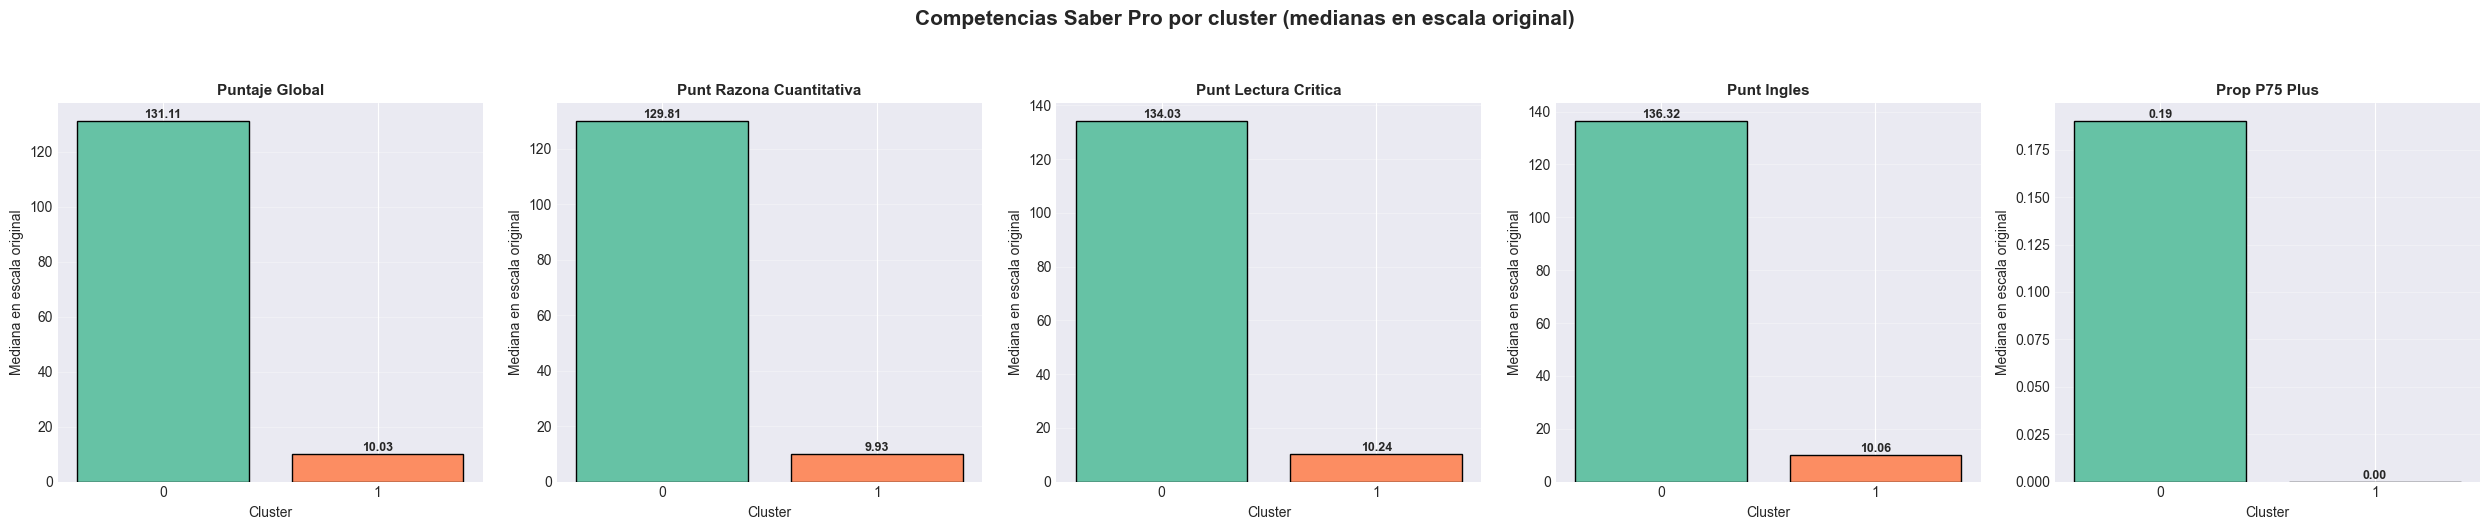

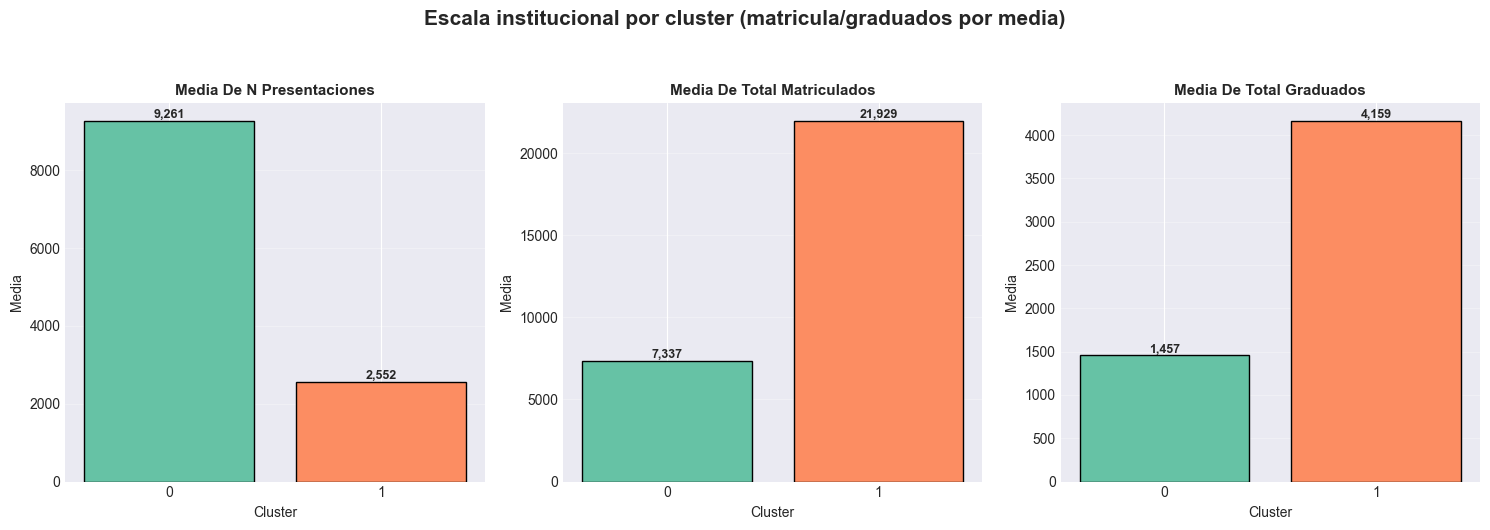

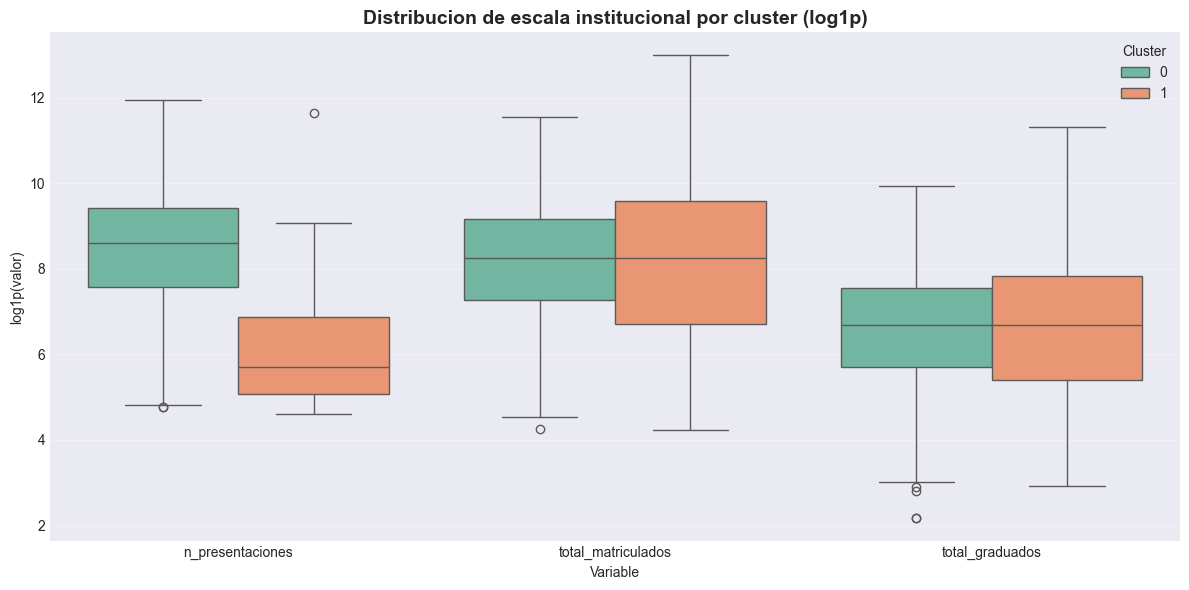

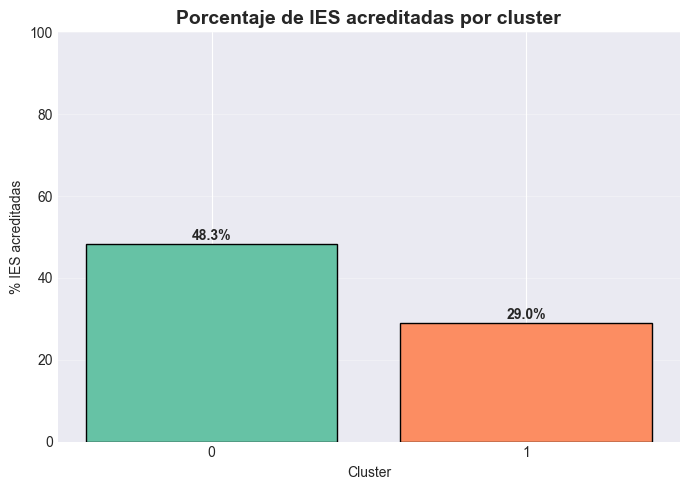

In [13]:
# ============================================================
# 8B. Visualizaciones corregidas de perfiles
# ============================================================
cluster_colors = sns.color_palette('Set2', n_colors=int(K_OPTIMO))
fecha = datetime.now().strftime("%Y%m%d")

# ---------- 1) Competencias: medianas en escala original ----------
fig, axes = plt.subplots(1, len(academic_vars), figsize=(5 * len(academic_vars), 5))
if len(academic_vars) == 1:
    axes = [axes]

for idx, feat in enumerate(academic_vars):
    vals = academic_median_profiles[feat]
    bars = axes[idx].bar(vals.index.astype(str), vals.values, color=cluster_colors, edgecolor='black')
    axes[idx].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Mediana en escala original')
    axes[idx].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Competencias Saber Pro por cluster (medianas en escala original)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / f'perfiles_clusters_competencias_mediana_{fecha}.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- 2) Escala institucional: medias ----------
scale_means = features_ies.groupby('cluster')[scale_vars].mean()

fig, axes = plt.subplots(1, len(scale_vars), figsize=(5 * len(scale_vars), 5))
if len(scale_vars) == 1:
    axes = [axes]

for idx, feat in enumerate(scale_vars):
    vals = scale_means[feat]
    bars = axes[idx].bar(vals.index.astype(str), vals.values, color=cluster_colors, edgecolor='black')
    axes[idx].set_title(f'Media de {feat}'.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Media')
    axes[idx].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,.0f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Escala institucional por cluster (matricula/graduados por media)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / f'perfiles_clusters_escala_media_{fecha}.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- 3) Escala institucional: distribucion log1p ----------
scale_long = features_ies.reset_index()[['cluster'] + scale_vars].melt(
    id_vars='cluster', var_name='variable', value_name='valor'
)
scale_long['log1p_valor'] = np.log1p(scale_long['valor'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=scale_long, x='variable', y='log1p_valor', hue='cluster', palette='Set2')
plt.title('Distribucion de escala institucional por cluster (log1p)', fontsize=14, fontweight='bold')
plt.xlabel('Variable')
plt.ylabel('log1p(valor)')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / f'perfiles_clusters_escala_boxplot_log_{fecha}.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- 4) Acreditacion: proporcion ----------
plt.figure(figsize=(7, 5))
vals = acred_profiles['porc_acreditadas']
bars = plt.bar(vals.index.astype(str), vals.values, color=cluster_colors, edgecolor='black')
plt.title('Porcentaje de IES acreditadas por cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('% IES acreditadas')
plt.ylim(0, max(100, vals.max() + 10))
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, vals.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'visualizaciones' / f'perfiles_clusters_acreditacion_prop_{fecha}.png', dpi=150, bbox_inches='tight')
plt.show()



### Interpretación de resultados, sección 8

#### Competencias Saber Pro — comparación por mediana

La comparación principal de competencias se hace con **medianas en escala original**, no con z-score. El resultado separa fuertemente los clusters:

| Variable | Cluster 0 | Cluster 1 | Diferencia C0 - C1 |
|---|---:|---:|---:|
| Puntaje global | 131.11 | 10.03 | +121.08 |
| Razonamiento cuantitativo | 129.81 | 9.93 | +119.88 |
| Lectura crítica | 134.03 | 10.24 | +123.79 |
| Inglés | 136.32 | 10.06 | +126.26 |
| Proporción P75+ | 0.19 | 0.00 | +0.19 |

Esto indica que el **cluster 0** concentra IES con desempeño académico claramente superior en Saber Pro. El **cluster 1** queda como grupo crítico: sus medianas están alrededor de 10 puntos en las competencias y prácticamente no concentra estudiantes en percentil 75+.

#### Escala institucional — matrícula y graduados por media

Para escala institucional se usa la **media**, como se solicitó, porque matrícula y graduados son variables muy asimétricas y la mediana se pegaba al valor imputado global.

| Variable | Cluster 0 | Cluster 1 | Lectura |
|---|---:|---:|---|
| IES en el cluster | 267 | 69 | Cluster 0 es mayoritario |
| Media de presentaciones | 9,261.42 | 2,551.68 | Cluster 0 presenta más estudiantes Saber Pro por IES |
| Media de matriculados | 7,337.25 | 21,928.62 | Cluster 1 tiene mayor matrícula promedio |
| Media de graduados | 1,456.68 | 4,158.50 | Cluster 1 tiene mayor graduación promedio |

La lectura sustantiva es importante: el **cluster 1 no es mejor por tener más matrícula/graduados promedio**. Más bien, combina mayor escala SNIES promedio con resultados Saber Pro muy bajos. Eso sugiere un grupo de instituciones grandes o con registros SNIES altos, pero con desempeño académico crítico.

#### Acreditación

La acreditación se interpreta como porcentaje, no como mediana:

| Cluster | IES acreditadas | Total IES | % acreditadas |
|---|---:|---:|---:|
| 0 | 129 | 267 | 48.3% |
| 1 | 20 | 69 | 29.0% |

El cluster 0 tiene una proporción de acreditación superior en **19.3 puntos porcentuales**. Esto es coherente con su mejor desempeño académico, aunque no implica causalidad directa.

#### Sobre el z-score

El z-score se conserva solo como referencia técnica. Sale negativo cuando un cluster está por debajo del promedio general de IES. En este caso, el cluster 1 tiene z-score académico negativo porque sus medianas de Saber Pro están muy por debajo del conjunto total. Sin embargo, para presentación e interpretación principal, la mediana cruda es más clara y queda como estándar de comparación.



## 9. Auditoria del Cluster de Desempeno Critico
Investigamos si los valores bajos del cluster de desempeno critico representan
anomalias de datos o el comportamiento real de ciertas instituciones.

### Interpretación de resultados exactos — auditoría del cluster crítico

El cluster crítico es el **cluster 1**, identificado por el peor perfil académico. La comparación por mediana muestra que este cluster tiene:

- Puntaje global mediano de **10.03**, frente a **131.11** en el cluster 0.
- Razonamiento cuantitativo mediano de **9.93**, frente a **129.81**.
- Lectura crítica mediana de **10.24**, frente a **134.03**.
- Inglés mediano de **10.06**, frente a **136.32**.
- Proporción P75+ mediana de **0.00**, frente a **0.19**.

Aunque el cluster 1 muestra mayor matrícula y graduados promedio, su perfil académico es sustancialmente inferior. Por eso la auditoría debe centrarse en revisar instituciones y programas de ese cluster, no en asumir que su mayor escala compensa el bajo desempeño.



In [14]:
# Identificar el cluster con peor desempeño académico robusto
# Usamos la mediana del z-score de puntaje_global, no el promedio crudo.
cluster_worst = cluster_z_profiles['puntaje_global'].idxmin()
cluster_worst_df = features_ies[features_ies['cluster'] == cluster_worst].copy()

print('='*70)
print(f'AUDITORIA DETALLADA: CLUSTER {cluster_worst} (DESEMPENO CRITICO)')
print('='*70)
print(f'Total de IES en Cluster {cluster_worst}: {len(cluster_worst_df)}')
print(f'Estadisticas del puntaje global en el Cluster {cluster_worst}:')
print(cluster_worst_df['puntaje_global'].describe())

print(f'\n--- IES con puntaje MAS BAJO (Top 10) ---')
display(cluster_worst_df.nsmallest(10, 'puntaje_global')[
    ['puntaje_global', 'punt_lectura_critica', 'punt_ingles', 'n_presentaciones', 'total_matriculados', 'total_graduados', 'es_acreditada']])

print(f'\n--- IES con puntaje MAS ALTO del Cluster {cluster_worst} (Top 5) ---')
display(cluster_worst_df.nlargest(5, 'puntaje_global')[
    ['puntaje_global', 'punt_lectura_critica', 'punt_ingles', 'n_presentaciones', 'total_matriculados', 'total_graduados', 'es_acreditada']])



AUDITORIA DETALLADA: CLUSTER 1 (DESEMPENO CRITICO)
Total de IES en Cluster 1: 69
Estadisticas del puntaje global en el Cluster 1:
count    69.000000
mean     25.076196
std      24.704018
min       9.321961
25%       9.794354
50%      10.026282
75%      42.337917
max      79.725000
Name: puntaje_global, dtype: float64

--- IES con puntaje MAS BAJO (Top 10) ---


,puntaje_global,punt_lectura_critica,punt_ingles,n_presentaciones,total_matriculados,total_graduados,es_acreditada
nombre_ies,,,,,,,
UNIVERSIDAD DE LA GUAJIRA,9.321961,9.528682,9.445039,129,14394.400000,1946.700000,1
ESCUELA MILITAR DE SUBOFICIALES SARGENTO INOCENCIO CHINCA-NILO,9.327950,9.232158,9.540426,1219,4477.636364,2190.818182,0
UNIVERSIDAD DEL MAGDALENA,9.354424,9.622469,9.368938,810,22132.500000,3859.800000,1
CORPORACION UNIVERSITARIA DEL CARIBE,9.475605,9.667516,9.566560,157,9793.000000,1717.500000,0
UNIVERSIDAD DE CORDOBA,9.506694,9.766204,9.586065,216,15704.000000,2076.600000,1
ESCUELA DE FORMACION DE INFANTERIA DE MARINA,9.516848,9.472121,9.558667,165,282.800000,170.600000,1
UNIVERSIDAD DE CARTAGENA,9.580018,9.810494,9.571102,1315,20194.000000,4098.900000,1
UNIVERSIDAD DE PAMPLONA,9.597095,9.798510,9.569190,1074,23834.400000,3356.600000,1
CORPORACION UNIVERSITARIA REGIONAL DEL CARIBE -IAFIC-,9.598745,9.647205,9.406832,161,228.285714,204.142857,0



--- IES con puntaje MAS ALTO del Cluster 1 (Top 5) ---


,puntaje_global,punt_lectura_critica,punt_ingles,n_presentaciones,total_matriculados,total_graduados,es_acreditada
nombre_ies,,,,,,,
ESCUELA DE COMUNICACIONES-FACATATIVA,79.725000,76.643210,84.788518,162,254.500000,104.000000,0
IE ESCUELA NORMAL SUPERIOR DE BUCARAMANGA SEDE C-BUCARAMANGA,78.205416,77.334122,78.614358,296,3878.077273,805.900000,0
ESCUELA NORMAL SUPERIOR LACIDES IRIARTE-SAHAGUN,77.091549,76.212676,75.409859,142,3878.077273,805.900000,0
CORPORACION INTERNACIONAL PARA EL DESARROLLO EDUCATIVO -CIDE-BOGOTÃ D.C.,76.862495,77.754967,80.178305,755,786.181818,181.454545,0
ESCUELA NORMAL SAN PEDRO ALEJANDRINO-SANTA MARTA,74.600949,74.310185,72.857685,108,3878.077273,805.900000,0


## 10. Almacenamiento del Modelo y Metricas
Guardamos el modelo entrenado (Pickle) y las metricas finales (JSON) para que puedan
ser consumidos en fases posteriores o puestos en produccion.

### Interpretación — almacenamiento de artefactos

El notebook exporta métricas, perfiles, visualizaciones y modelo para garantizar reproducibilidad. Esto permite:

- auditar cómo se construyeron los clusters;
- reutilizar perfiles en informes o dashboards;
- comparar futuras versiones del modelo;
- mantener trazabilidad entre datos, código y resultados.

Los archivos corregidos de perfiles y visualizaciones quedan en `artifacts/metricas` y `artifacts/visualizaciones`.



In [15]:
# Estructura del modelo para exportacion
modelo_clustering = {
    'modelo': kmeans_final,
    'scaler': scaler,
    'pca': pca,
    'n_components_pca': N_COMPONENTS,
    'feature_names': features_ies.columns[:-1].tolist(),
    'labels': labels_final
}

fecha = datetime.now().strftime("%Y%m%d")
with open(ARTIFACTS_DIR / 'modelos' / f'clasificacion_ies_cluster_{fecha}.pkl', 'wb') as f:
    pickle.dump(modelo_clustering, f)

# Metricas JSON
metricas_clustering = {
    "metadata": {
        "modelo": "kmeans_ies_desempeno_pca",
        "fecha_entrenamiento": datetime.now().isoformat(),
        "autor": "German",
        "issue": "Sprint 7.2 - Clustering IES por desempeno (con PCA reducido)"
    },
    "datos": {
        "n_samples": int(len(features_ies)),
        "n_features_originales": int(X_scaled.shape[1]),
        "n_componentes_pca": int(N_COMPONENTS),
        "varianza_retenida_pca": float(pca.explained_variance_ratio_.sum()),
        "periodo": "2015-2024",
        "fuentes": ["Saber Pro", "SNIES"],
        "regla_matricula": "Sem1 todas IES + Sem2 solo SENA (MEN)"
    },
    "hiperparametros": {
        "algoritmo": "KMeans",
        "n_clusters": int(K_OPTIMO),
        "random_state": 42,
        "input_space": "PCA reduced"
    },
    "metricas_clustering": {
        "silhouette_score": float(silh_final),
        "davies_bouldin_index": float(db_final),
        "calinski_harabasz_score": float(ch_final)
    },
    "distribucion_clusters": {str(k): int(v) for k, v in features_ies['cluster'].value_counts().to_dict().items()},
    "features_utilizadas": features_ies.columns[:-1].tolist()
}

with open(ARTIFACTS_DIR / 'metricas' / f'metricas_clustering_{fecha}.json', 'w') as f:
    json.dump(metricas_clustering, f, indent=2)

print(f"\nModelo y metricas exportados exitosamente:")
print(f"  Modelo:   artifacts/modelos/clasificacion_ies_cluster_{fecha}.pkl")
print(f"  Metricas: artifacts/metricas/metricas_clustering_{fecha}.json")
print(f"\nResumen final:")
print(f"  {len(features_ies)} IES -> {K_OPTIMO} clusters")
print(f"  {X_scaled.shape[1]} features -> {N_COMPONENTS} componentes PCA ({pca.explained_variance_ratio_.sum()*100:.1f}% varianza)")
print(f"  Silhouette: {silh_final:.3f}")


Modelo y metricas exportados exitosamente:
  Modelo:   artifacts/modelos/clasificacion_ies_cluster_20260527.pkl
  Metricas: artifacts/metricas/metricas_clustering_20260527.json

Resumen final:
  336 IES -> 2 clusters
  9 features -> 2 componentes PCA (79.1% varianza)
  Silhouette: 0.675
